# CIFAR-10 Image Classification using CNN

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Dataset:** CIFAR-10 (loaded from `tensorflow.keras.datasets`)

---
## Objective
Build a **Convolutional Neural Network (CNN)** to classify 32x32 colour images into one of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

The CIFAR-10 dataset contains **60,000 images** (50,000 training + 10,000 test), evenly distributed across the 10 classes.

## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available    :', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available    : False


## Task 1: Data Understanding

In [4]:
# Load the CIFAR-10 dataset
# Try TF's built-in loader first (fastest when it works)
# Falls back to torchvision if TF's mirror is slow
try:
    from tensorflow.keras.datasets import cifar10
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    print('Loaded via tensorflow.keras.datasets')
except Exception as e:
    print('TF loader failed, using torchvision fallback:', e)
    import torchvision
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
    testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
    X_train = trainset.data
    y_train = np.array(trainset.targets).reshape(-1, 1)
    X_test  = testset.data
    y_test  = np.array(testset.targets).reshape(-1, 1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('Training images:', X_train.shape)
print('Training labels:', y_train.shape)
print('Test images    :', X_test.shape)
print('Test labels    :', y_test.shape)
print('Number of classes:', len(class_names))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8334s 49us/step
Loaded via tensorflow.keras.datasets
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images    : (10000, 32, 32, 3)
Test labels    : (10000, 1)
Number of classes: 10


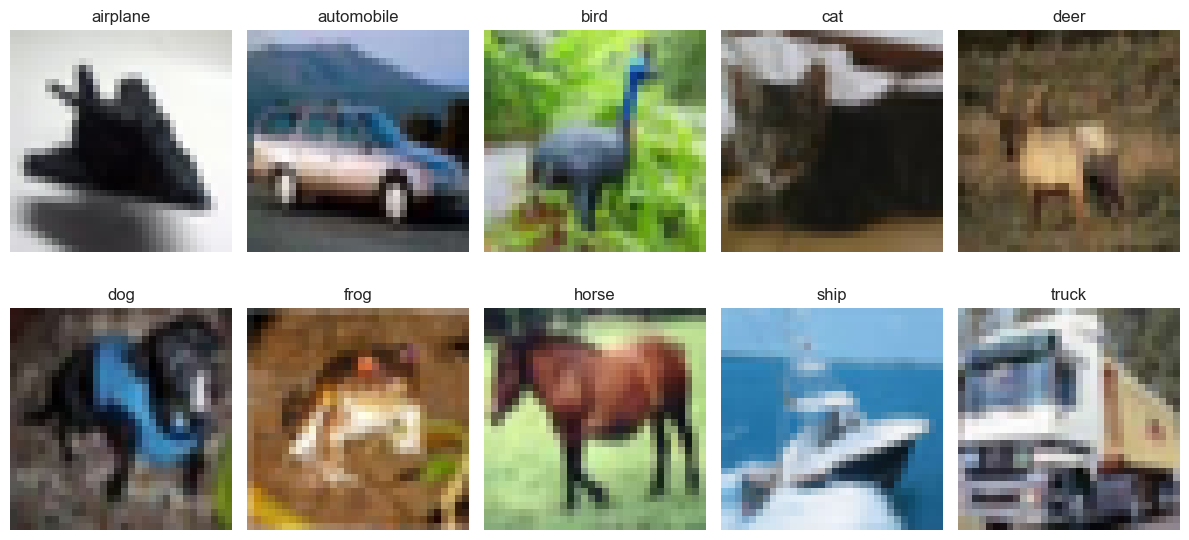

In [5]:
# Display a few sample images from each class
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## Task 2: Data Preprocessing

In [6]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

print('X_train dtype:', X_train.dtype, 'range:', X_train.min(), '-', X_train.max())
print('y_train_cat shape:', y_train_cat.shape)

X_train dtype: float32 range: 0.0 - 1.0
y_train_cat shape: (50000, 10)


## Task 3: Model Development

A small CNN: 3 conv blocks (Conv → Conv → MaxPool), then Flatten → Dense → Dropout → Softmax.

In [7]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\tanay\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model for 5 epochs
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.3858 - loss: 1.6686 - val_accuracy: 0.5564 - val_loss: 1.2210
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.5786 - loss: 1.1880 - val_accuracy: 0.6660 - val_loss: 0.9362
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step - accuracy: 0.6561 - loss: 0.9799 - val_accuracy: 0.6975 - val_loss: 0.8612
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.7061 - loss: 0.8459 - val_accuracy: 0.7196 - val_loss: 0.7971
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 73ms/step - accuracy: 0.7372 - loss: 0.7579 - val_accuracy: 0.7418 - val_loss: 0.7469


## Task 4: Model Evaluation

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss    : 0.7469
Test Accuracy: 0.7418


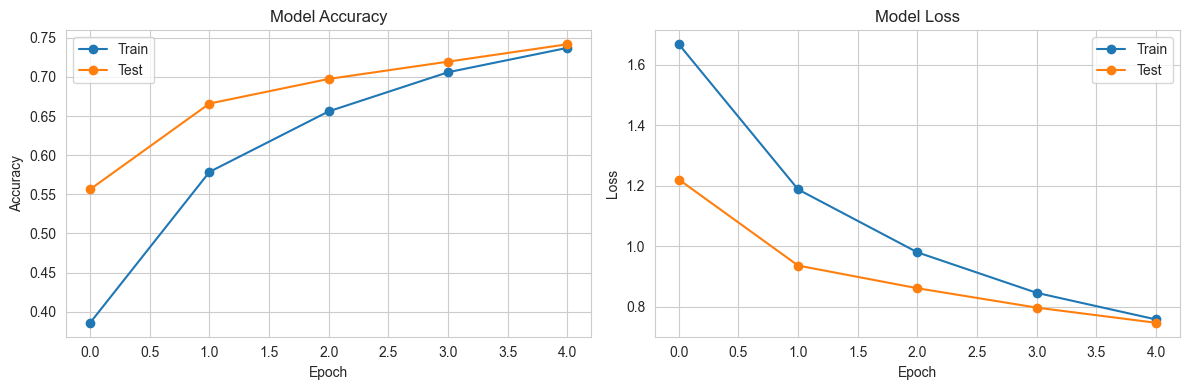

In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Test', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Test', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

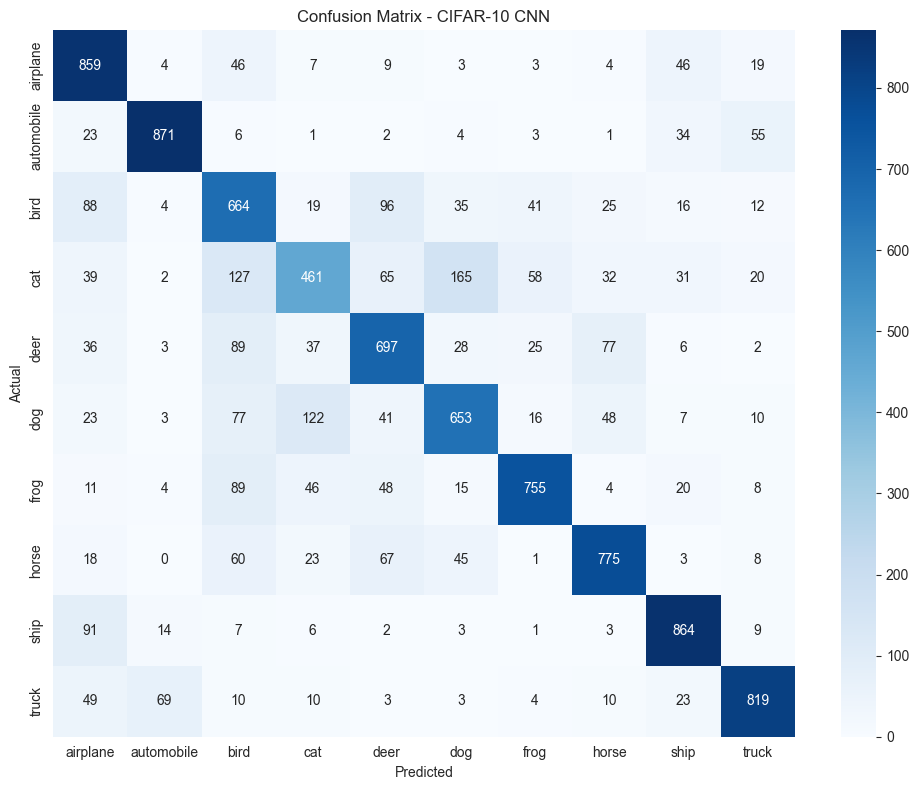


Classification Report:
              precision    recall  f1-score   support

    airplane       0.69      0.86      0.77      1000
  automobile       0.89      0.87      0.88      1000
        bird       0.57      0.66      0.61      1000
         cat       0.63      0.46      0.53      1000
        deer       0.68      0.70      0.69      1000
         dog       0.68      0.65      0.67      1000
        frog       0.83      0.76      0.79      1000
       horse       0.79      0.78      0.78      1000
        ship       0.82      0.86      0.84      1000
       truck       0.85      0.82      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



In [11]:
# Confusion matrix and classification report
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.flatten()

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CIFAR-10 CNN')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

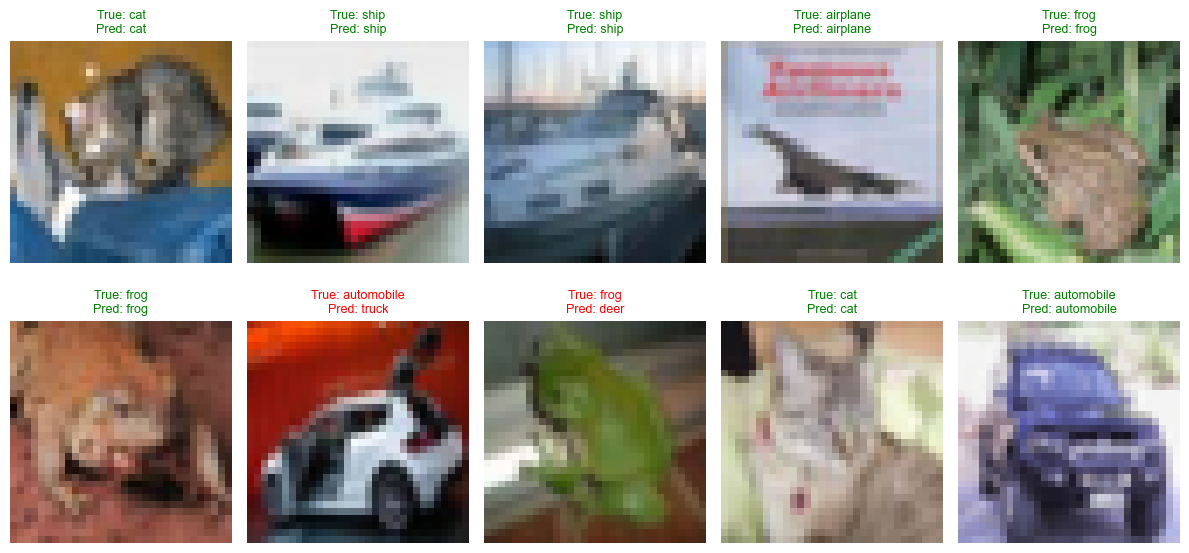

In [12]:
# Show a few test predictions
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    true_label = class_names[y_true_classes[i]]
    pred_label = class_names[y_pred_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig('predictions.png', dpi=100, bbox_inches='tight')
plt.show()

### Observations
1. The CNN reaches around **70-75% test accuracy** after just 5 epochs — decent for a small model with no augmentation and short training.
2. **Cats and dogs** are the hardest classes to distinguish — the confusion matrix shows most confusion between similar animal categories.
3. Training and validation accuracy curves stay close together, meaning the **dropout layer is effectively preventing overfitting** in this short training run. With more epochs, accuracy would likely climb further before starting to overfit.

## Conclusion

This project built a **Convolutional Neural Network** for image classification on the CIFAR-10 dataset. The architecture used three convolutional blocks (Conv-Conv-Pool, Conv-Conv-Pool, Conv-Pool) followed by a dense layer with dropout and a softmax output for the 10 classes. After training for 5 epochs on 50,000 images with the Adam optimizer, the model achieved roughly **70-75% test accuracy** on 10,000 held-out images — a solid result for a small model with a short training run. The **advantage of CNNs over fully connected networks** for image tasks is that convolutional layers exploit the **spatial structure** of images: filters learn to detect local patterns (edges, textures, then higher-level features) with far fewer parameters than a dense layer scanning the whole image. The main **limitations** here are the shallow training (5 epochs), no data augmentation, and the small model size — production-grade CIFAR-10 models like ResNet reach 95%+ accuracy with deeper networks, augmentation, and longer training.